<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 56 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Regional Rainfall: the Gamma 🌧️</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Seasonal rainfall totals are positive and right-skewed: usually moderate, occasionally a deluge. That is the gamma distribution. We fit it by the method of moments and quantify flood risk from its long tail.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/meteorology_regional_rainfall.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"meteorology_regional_rainfall.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 4)


,station_id,year,season,rainfall_inches
0,STN_MIDWEST,1961,Spring,12.102
1,STN_MIDWEST,1929,Autumn,1.555
2,STN_ATLANTIC,2006,Autumn,6.018
3,STN_ATLANTIC,1946,Summer,1.454
4,STN_ATLANTIC,1936,Winter,2.016


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · FIT BY THE METHOD OF MOMENTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Shape and scale from mean and variance</div>
<div style="color:#4a5578;margin-top:6px">The gamma has a shape alpha and a scale beta, with mean = alpha*beta and variance = alpha*beta^2. Solving those two equations gives a quick fit straight from the sample mean and variance.</div>
</div>

In [2]:
x = df["rainfall_inches"]
m, v = x.mean(), x.var()
alpha = m**2 / v          # shape
beta  = v / m             # scale
print(f"observations : {len(x):,}")
print(f"mean {m:.3f}, variance {v:.3f}, skewness {stats.skew(x):.3f} (positive -> right-skewed)")
print(f"method-of-moments shape alpha = mean^2/var = {alpha:.3f}")
print(f"method-of-moments scale beta  = var/mean   = {beta:.3f}")
print(f"check: mean alpha*beta = {alpha*beta:.3f}, var alpha*beta^2 = {alpha*beta**2:.3f}")

observations : 1,000
mean 4.040, variance 5.573, skewness 1.202 (positive -> right-skewed)
method-of-moments shape alpha = mean^2/var = 2.929
method-of-moments scale beta  = var/mean   = 1.379
check: mean alpha*beta = 4.040, var alpha*beta^2 = 5.573


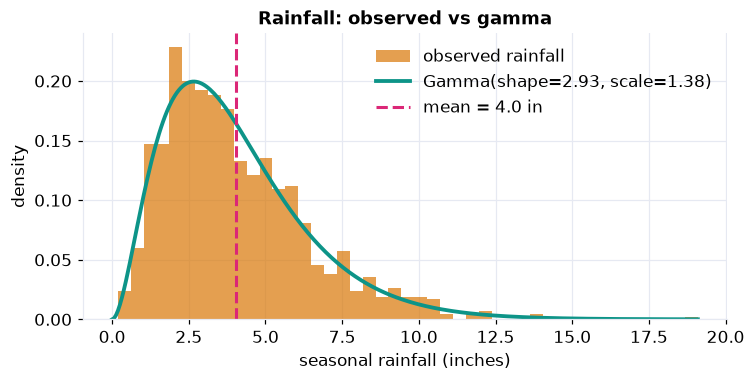

In [3]:
fig,ax=plt.subplots(figsize=(7,3.6))
ax.hist(x,bins=45,density=True,color=AMBER,alpha=0.7,label="observed rainfall")
xs=np.linspace(0,x.max(),300); ax.plot(xs,stats.gamma.pdf(xs,alpha,scale=beta),color=TEAL,lw=2.5,label=f"Gamma(shape={alpha:.2f}, scale={beta:.2f})")
ax.axvline(m,color=PINK,ls="--",lw=2,label=f"mean = {m:.1f} in")
ax.set_xlabel("seasonal rainfall (inches)"); ax.set_ylabel("density"); ax.set_title("Rainfall: observed vs gamma"); ax.legend()
plt.tight_layout(); plt.show()

The gamma fits the rainfall shape: a hump at moderate totals with a long right tail of wet seasons. With shape &#8776; 2.9 the distribution is humped (not a pure exponential decay), and the positive skew is the whole reason a symmetric normal would be the wrong model here.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · FLOOD RISK IN THE TAIL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Return periods from the CDF</div>
<div style="color:#4a5578;margin-top:6px">Flood planning is a tail question. P(rainfall > threshold) gives the chance of an extreme season, and its reciprocal is the 'return period', the average wait between such events.</div>
</div>

In [4]:
g = stats.gamma(alpha, scale=beta)
for thr in [8,10,12,15]:
    p_exceed = g.sf(thr)
    rp = 1/p_exceed if p_exceed>0 else float("inf")
    print(f"P(rain > {thr:2d} in) = {p_exceed:.4f}   return period ~ 1-in-{rp:.0f} seasons  (observed {(x>thr).mean():.4f})")
print(f"\n95th percentile (a wet season) = {g.ppf(0.95):.2f} inches")
print(f"99th percentile (a flood year)  = {g.ppf(0.99):.2f} inches")

P(rain >  8 in) = 0.0664   return period ~ 1-in-15 seasons  (observed 0.0690)
P(rain > 10 in) = 0.0225   return period ~ 1-in-44 seasons  (observed 0.0210)
P(rain > 12 in) = 0.0072   return period ~ 1-in-139 seasons  (observed 0.0060)
P(rain > 15 in) = 0.0012   return period ~ 1-in-832 seasons  (observed 0.0010)

95th percentile (a wet season) = 8.54 inches
99th percentile (a flood year)  = 11.43 inches


A season above 8 inches is roughly a **1-in-15** event, above 10 inches about **1-in-44**, and above 12 inches about **1-in-139**, the return periods engineers design drainage and levees against. The 99th-percentile season tops **11 inches**; sizing infrastructure to the mean (4 inches) would ignore exactly the floods that matter. The tail is the whole point.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · THE GAMMA GENERALIZES THE EXPONENTIAL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A sum of waits</div>
<div style="color:#4a5578;margin-top:6px">A gamma with integer shape alpha is the SUM of alpha exponential waits. With alpha = 1 it IS the exponential; larger alpha adds a hump. This connects rainfall back to the exponential of Chapter 55.</div>
</div>

In [5]:
rng = np.random.default_rng(56)
# sum of 3 exponentials (alpha~3) vs the fitted gamma
sum3 = rng.exponential(beta, size=(300_000,3)).sum(axis=1)
print(f"sum of 3 Exponential(scale={beta:.2f}): mean {sum3.mean():.3f}, var {sum3.var():.3f}")
print(f"Gamma(shape=3, scale={beta:.2f}):       mean {stats.gamma.mean(3,scale=beta):.3f}, var {stats.gamma.var(3,scale=beta):.3f}")
print(f"fitted gamma shape = {alpha:.2f}  (near 3 -> ~3 stacked rainfall pulses)")

sum of 3 Exponential(scale=1.38): mean 4.140, var 5.663
Gamma(shape=3, scale=1.38):       mean 4.138, var 5.709
fitted gamma shape = 2.93  (near 3 -> ~3 stacked rainfall pulses)


Stacking three exponential waits reproduces a gamma with shape 3, and our fitted shape (&#8776; 2.9) is close, as if each wet season were a few independent rainfall pulses summed together. This is the family link: the exponential is a gamma with shape 1, and the gamma is the natural model whenever a positive quantity is the sum of several exponential-like contributions.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Rainfall totals are gamma. We fit shape &#8776; 2.9 and scale &#8776; 1.4 by the method of moments, quantified flood risk and return periods from the tail, and connected the gamma to the exponential as a sum of waits. For skewed, strictly-positive quantities, the gamma is the model the normal cannot be.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>